In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("=== DATASET SUMMARY ===")
print(df.describe())

=== DATASET SUMMARY ===
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [4]:
survival = df['Survived'].value_counts()
print("Survived:", survival[1])
print("Did not Survive:", survival[0])
print(f"Survival Rate: {survival[1]/len(df)*100:.1f}%")

Survived: 342
Did not Survive: 549
Survival Rate: 38.4%


Survival Rate by Gender:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


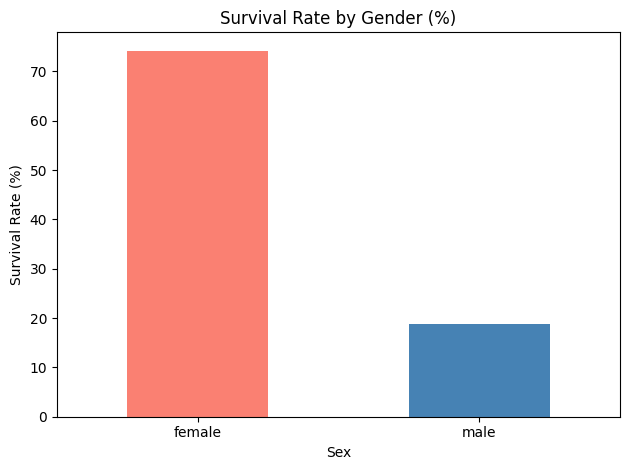

In [5]:
gender_survival = df.groupby('Sex')['Survived'].mean()*100
print("Survival Rate by Gender:")
print(gender_survival.round(1))

gender_survival.plot(kind='bar', color=['salmon','steelblue'],
                     title='Survival Rate by Gender (%)')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('survival_by_gender.png')
plt.show()

Survival Rate by Class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


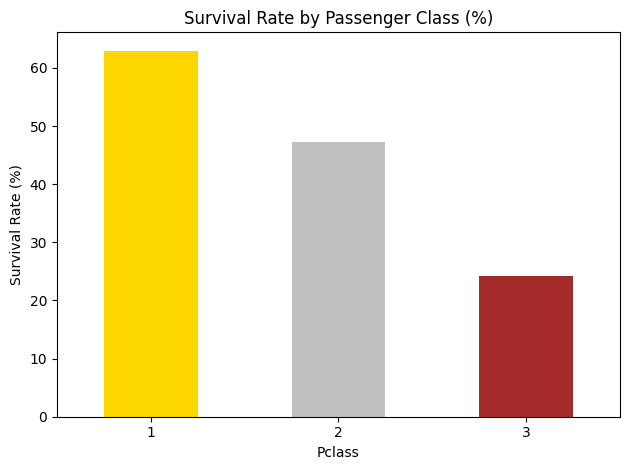

In [6]:
class_survival = df.groupby('Pclass')['Survived'].mean()*100
print("Survival Rate by Class:")
print(class_survival.round(1))

class_survival.plot(kind='bar', color=['gold','silver','brown'],
                    title='Survival Rate by Passenger Class (%)')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('survival_by_class.png')
plt.show()

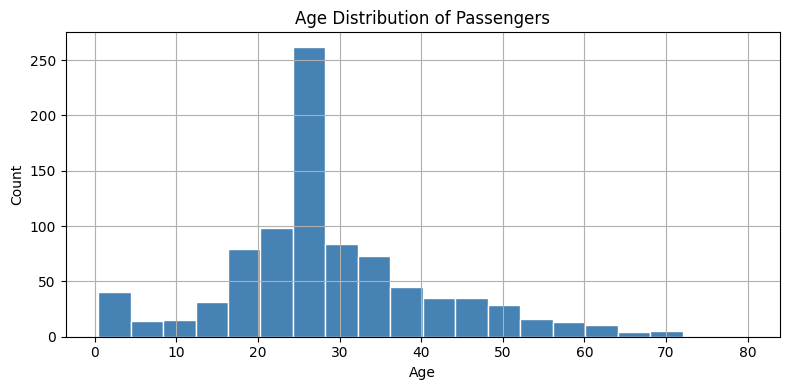

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

plt.figure(figsize=(8,4))
df['Age'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

Average Fare by Class:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64


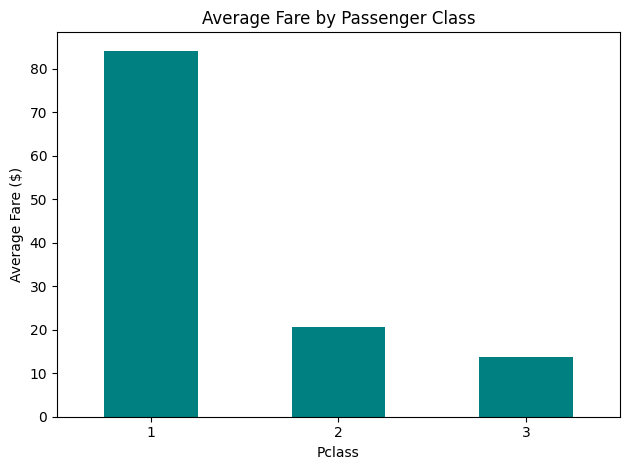

In [9]:
avg_fare = df.groupby('Pclass')['Fare'].mean()
print("Average Fare by Class:")
print(avg_fare.round(2))

avg_fare.plot(kind='bar', color='teal',
              title='Average Fare by Passenger Class')
plt.ylabel('Average Fare ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fare_by_class.png')
plt.show()

In [10]:
print("=== KEY BUSINESS INSIGHTS ===")
print(f"1. Overall Survival Rate: {df['Survived'].mean()*100:.1f}%")
print(f"2. Female Survival Rate: {df[df['Sex']=='female']['Survived'].mean()*100:.1f}%")
print(f"3. Male Survival Rate: {df[df['Sex']=='male']['Survived'].mean()*100:.1f}%")
print(f"4. 1st Class Survival Rate: {df[df['Pclass']==1]['Survived'].mean()*100:.1f}%")
print(f"5. 3rd Class Survival Rate: {df[df['Pclass']==3]['Survived'].mean()*100:.1f}%")
print(f"6. Average Age: {df['Age'].mean():.1f} years")
print(f"7. Average Fare: ${df['Fare'].mean():.2f}")

=== KEY BUSINESS INSIGHTS ===
1. Overall Survival Rate: 38.4%
2. Female Survival Rate: 74.2%
3. Male Survival Rate: 18.9%
4. 1st Class Survival Rate: 63.0%
5. 3rd Class Survival Rate: 24.2%
6. Average Age: 29.4 years
7. Average Fare: $32.20
